Universidade do Vale do Itajaí<br>
PPGCA - Programa de Pós-Graduação em Computação Aplicada<br>
Aprendizado Profundo<br>
Prof. Felipe Viel<br>
Conteúdo: Redes Neurais Profundas<br>


# Exercício: Redes Profundas

Neste exercício você irá construir modelos de redes neurais para realizar classificação e experimentar diversas configurações de hiperparâmetros.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
from sklearn.neural_network import MLPClassifier

import sys
print('Python version:', sys.version.split(' ')[0])

import tensorflow as tf
print('TensorFlow version:', tf.__version__)

# Find out NVIDIA GPU model (randomly assigned by Colab)
# Deep learning performance: T4 < L4 < A100 < G4 < H100
# https://ai-benchmark.com/ranking_deeplearning.html
gpu = !nvidia-smi -L
gpu = gpu[0].split(' (')[0]
if 'failed' in gpu:
  print('GPU: None')
else:
  print(gpu, '\n')
  # GPU information
  !nvidia-smi

Python version: 3.13.15
TensorFlow version: 2.20.0
GPU 0: NVIDIA L4 

Wed Aug 26 21:57:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   42C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |  

# 1. Conjunto de dados #1

Para "aquecer", vamos começar utilizando o conjunto XOR do exercício anterior.

In [2]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
X_train, y_train = make_blobs(n_samples=400, n_features=2, centers=[[0,0],[1,1],[0,1],[1,0]], cluster_std=0.15, random_state=0)
y_train = (y_train >= 2).astype(int)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=1/4, random_state=0)
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)

(300, 2) (300,)
(100, 2) (100,)


1. Usando a biblioteca sklearn, treine uma rede neural de 2 camadas (1 oculta) para classificação. Utilize o otimizador Adam com parâmetros padrão, exceto pela taxa de aprendizado (constante), que deve ser escolhida apropriadamente. Obtenha 100% de acurácia de treinamento e de validação e calcule o valor da perda ao final do treinamento. Além disso, trace a curva da perda de treinamento ao longo das épocas.

#### Dicas
- Para obter a curva de perda no treinamento, você pode utilizar `model.loss_curve_`.
- Note que o sklearn usa uma terminologia por vezes inconsistente com a literatura da área (mas consistente internamente em sua API). Por exemplo, o parâmetro `max_iter` corresponde ao número de épocas, não necessariamente ao número de atualizações de pesos. Outro aspecto incômodo é juntar todos os hiperparâmetros do treinamento dentro da definição do modelo, o que além de tornar a chamada extensa, faz com que, dependendo da configuração, alguns parâmetros se tornem desnecessários ou mudem de definição.

In [3]:
model = MLPClassifier(
    hidden_layer_sizes=(50,),
    activation="relu",
    solver="adam",
    learning_rate="constant",
    learning_rate_init=0.01,
    alpha=0,
    max_iter=2000,
    random_state=42,
    tol=1e-7
)

model.fit(X_train, y_train)

MLPClassifier(alpha=0, hidden_layer_sizes=(50,), learning_rate_init=0.01,
              max_iter=2000, random_state=42, tol=1e-07)

In [4]:
print("Train accuracy: {:.1%}".format(model.score(X_train, y_train)))
print("  Val accuracy: {:.1%}".format(model.score(X_val, y_val)))
print("Epochs actually performed: {}".format(model.n_iter_))

Train accuracy: 100.0%
  Val accuracy: 100.0%
Epochs actually performed: 1852


In [5]:
loss_values = np.asarray(model.loss_curve_)
epoch_values = np.arange(1, len(loss_values) + 1)

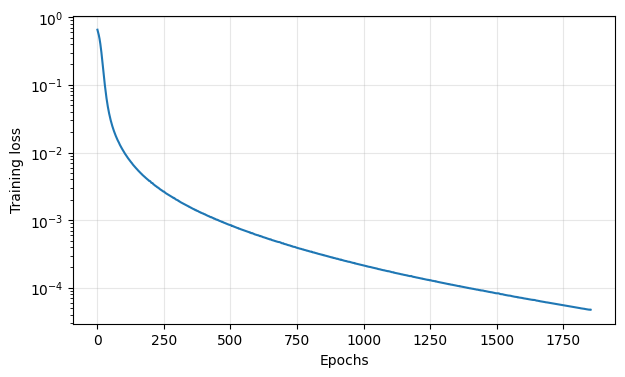

Final loss: 0.000048


In [6]:
plt.figure(figsize=(7, 4))
plt.plot(epoch_values, loss_values)
plt.yscale("log")
plt.xlabel("Epochs")
plt.ylabel("Training loss")
plt.grid(True, alpha=0.3)
plt.show()
print("Final loss: {:.6f}".format(model.loss_))

2. Repita o item anterior usando [Keras](https://keras.io/), a API de alto-nível do [TensorFlow](https://www.tensorflow.org/), disponível através do módulo `tensorflow.keras`. Certifique-se de estar usando TensorFlow 2.x.


### Dicas
- Ao invés de instalar o TensorFlow e rodar localmente em sua máquina, uma opção mais simples é utilizar o serviço em nuvem gratuito [Google Colab](https://colab.research.google.com), que já possui todas as bibliotecas necessárias instaladas, inclusive o TensorFlow 2.x.

- Leia a documentação do Keras para aprender a utilizá-lo. Para quem está começando, é recomendável (e suficiente para este exercício) usar a classe [Sequential](https://keras.io/guides/sequential_model). É útil também conhecer sobre funções de [ativação](https://keras.io/activations), funções de [perda](https://keras.io/losses), métodos de [otimização](https://keras.io/api/optimizers) e o processo de [treinamento e avaliação](https://keras.io/guides/training_with_built_in_methods/) de modelos.
- No Keras, ao contrário do sklearn, é necessário especificar explicitamente a camada de saída, sua função de ativação, e a função de perda utilizada. (No sklearn, essa escolha é automática a partir dos valores encontrados em `y_train`.)
- É recommendável utilizar o comando `model.summary()` para obter uma descrição de todas as camadas da rede neural.
- Para configurar a taxa de aprendizado, é necessário instanciar um otimizador, caso contrário será usado o valor padrão.
- Para obter a curva de perda no treinamento, utilize
```python
history = model.fit(...)
history.history['loss']
```
- Se quiser garantir a reprodutibilidade (desde que não esteja usando GPU), utilize `tf.random.set_seed()` **antes** de definir o modelo (os pesos são inicializados no momento da adição de cada camada).


In [7]:
import keras
from keras import layers


In [8]:
keras.utils.set_random_seed(42)

model = keras.Sequential()
model.add(keras.Input(shape=(2,)))
model.add(layers.Dense(10, activation="relu", name="layer1"))
model.add(layers.Dense(1, activation="sigmoid", name="output"))

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss=keras.losses.BinaryCrossentropy(), metrics=["accuracy"])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(X_train, y_train, epochs=500)

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.6733 - loss: 0.6228
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7400 - loss: 0.5812 
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8167 - loss: 0.5375 
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8900 - loss: 0.4887 
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9500 - loss: 0.4340 
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9800 - loss: 0.3767 
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9833 - loss: 0.3211 
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9967 - loss: 0.2700 
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.2246 
Epoch 10/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.1851 
Epoch 11/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.1520 
Epoch 12/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

In [10]:
train_loss, train_acc = model.evaluate(X_train, y_train)
val_loss, val_acc = model.evaluate(X_val, y_val)

print("Train accuracy: ", train_acc)
print("Val accuracy: ", val_acc)
print("Final training loss:", train_loss)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 1.0000 - loss: 1.1552e-04
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 1.0000 - loss: 9.3482e-04
Train accuracy:  1.0
Val accuracy:  1.0
Final training loss: 0.0001155162972281687


In [11]:
loss_history = history.history["loss"]
epochs_values = np.arange(1, len(loss_history) + 1)

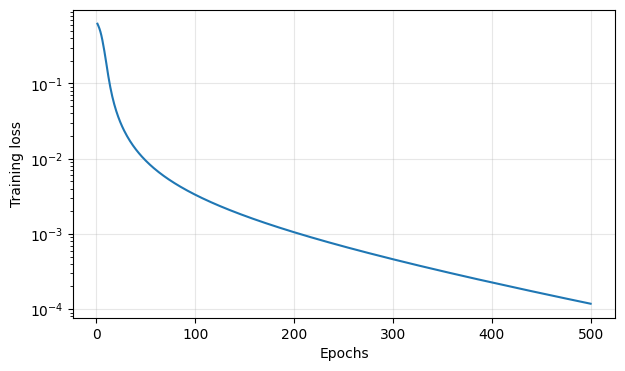

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(epochs_values, loss_history)
plt.yscale("log")
plt.xlabel("Epochs")
plt.ylabel("Training loss")
plt.grid(True, alpha=0.3)
plt.show()

# 2. Conjunto de dados #2

A partir de agora, desenvolva seus modelos de aprendizado profundo utilizando o Keras/TensorFlow, o qual possui muito mais recursos do que o sklearn e é mais otimizado para desempenho.

O segundo conjunto de dados é o conjunto de dígitos manuscritos [MNIST](https://en.wikipedia.org/wiki/MNIST_database), o qual possui 70000 amostras, sendo 10000 amostras de teste. Este é um conjunto clássico e -- embora não seja mais recomendado para avaliação do estado da arte -- ainda vastamente utilizado para experimentação e aprendizado. O conjunto pode ser facilmente carregado pelos comandos abaixo.

In [13]:
from tensorflow.keras.datasets import mnist
(x_train_full, y_train_full), (x_test_full, y_test_full) = mnist.load_data()
x_train_full = x_train_full / 255
x_test_full = x_test_full / 255
print(x_train_full.shape, y_train_full.shape)
print(x_test_full.shape, y_test_full.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


Observe a diferença na notação convencional quando usamos o Keras (ou qualquer outro *framework* de aprendizado profundo): `x` (minúsculo) ao invés de `X` (maiúsculo). Isto ocorre porque o Keras nos permite trabalhar diretamente com os dados em seu formato original, neste caso, como um tensor 3D. Portanto, não é necessário redimensionar (*reshape*) os dados antes de aplicar o modelo, assim como perde o sentido usar uma notação especial para denotar uma matriz (tensor 2D).

Caso seja necessário redimensionar os dados em algum estágio do modelo, isso pode ser feito internamente com camadas do Keras. Em particular, para redimensionar para o formato convencional de tensor 2D `(n_samples, n_features)`, pode ser usada a camada `Flatten`. Isto é sempre necessário antes de aplicar uma camada `Dense`, a qual só opera na última dimensão. No nosso caso, as duas dimensões (28,28) serão "achatadas" em uma única de (784,):

In [14]:
from tensorflow.keras.layers import Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
model = Sequential()
model.add(Input(shape=(28,28)))
model.add(Flatten())
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

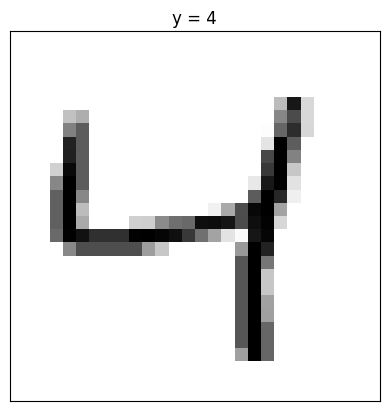

In [15]:
# Exemplo de uma imagem
i = 2
plt.imshow(x_train_full[i], cmap=plt.cm.gray_r);
plt.title('y = {}'.format(y_train_full[i]));
plt.xticks([]);
plt.yticks([]);

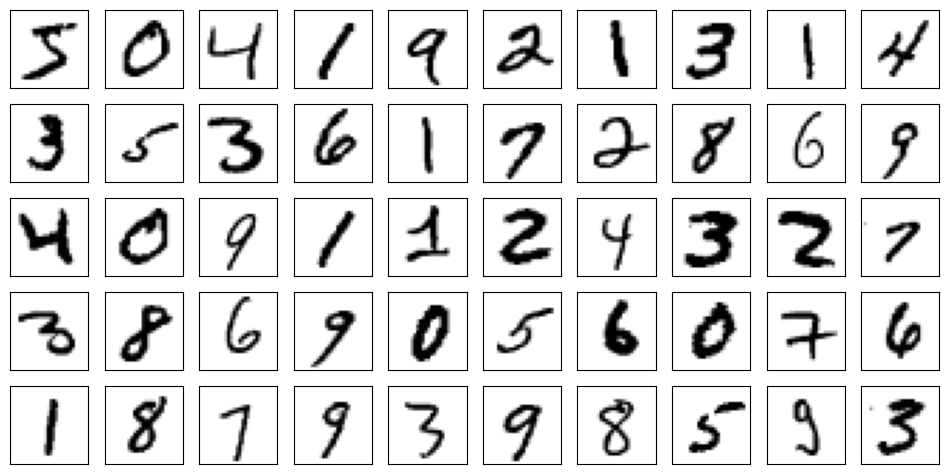

In [18]:
plt.figure(figsize=(12,12))
for i in range(50):
    plt.subplot(10,10,i+1)
    plt.imshow(x_train_full[i], cmap=plt.cm.gray_r);
    plt.xticks([]);
    plt.yticks([]);

## Tarefas

1. Separe um conjunto de validação com 5000 amostras (por exemplo, as últimas 5000 amostras do conjunto de treinamento). Confirme que a distribuição das classes é parecida com a do conjunto de treinamento (não precisa ser exatamente igual).

#### Dica
- Para calcular e visualizar um histograma, você pode utilizar a função `plt.hist()`, opcionalmente definindo os parâmetros `density` e `alpha`, entre outros.

In [19]:
# Mantemos o conjunto original intacto e criamos explicitamente
# os conjuntos de treinamento e validação.
x_train = x_train_full[:55000]
y_train = y_train_full[:55000]
x_val = x_train_full[55000:]
y_val = y_train_full[55000:]

print("Train:", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)

Train: (55000, 28, 28) (55000,)
Validation: (5000, 28, 28) (5000,)


Proporção por classe - treinamento:
[0.0988     0.11294545 0.09936364 0.10221818 0.09714545 0.09023636
 0.09883636 0.10367273 0.0974     0.09938182]
Proporção por classe - validação:
[0.0978 0.106  0.0986 0.1018 0.0998 0.0916 0.0964 0.1126 0.0988 0.0966]


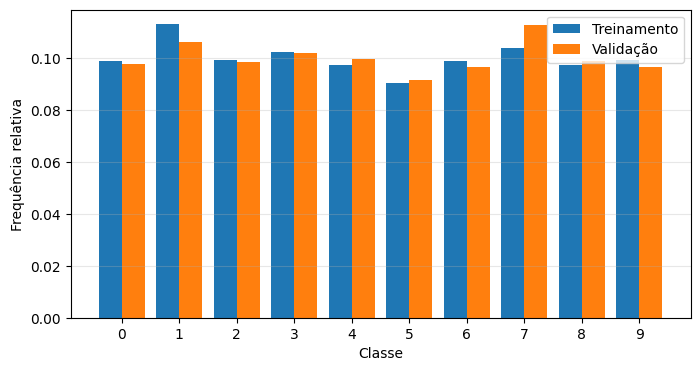

In [20]:
classes = np.arange(10)
train_counts = np.bincount(y_train, minlength=10)
val_counts = np.bincount(y_val, minlength=10)

print("Proporção por classe - treinamento:")
print(train_counts / len(y_train))
print("Proporção por classe - validação:")
print(val_counts / len(y_val))

plt.figure(figsize=(8, 4))
plt.bar(classes - 0.2, train_counts / len(y_train), width=0.4, label="Treinamento")
plt.bar(classes + 0.2, val_counts / len(y_val), width=0.4, label="Validação")
plt.xlabel("Classe")
plt.ylabel("Frequência relativa")
plt.xticks(classes)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

2. Para desenvolvimento do modelo, considere um subconjunto de treinamento com poucas amostras, por exemplo, as primeiras 10000, e também um número pequeno de épocas, por exemplo, 10. Isso vai permitir uma rápida experimentação. Uma vez finalizado o desenvolvimento, você poderá aumentar esses valores. Inicialmente, construa um modelo **baseline** sem nenhuma camada oculta, treine-o e confirme que está funcionando corretamente.
1. Por hora, ignore o conjunto de validação. Tente obter 100% de acurácia de treinamento (com o conjunto reduzido) e apenas 10 épocas. O objetivo é garantir que o modelo possui capacidade suficiente para este problema. Fique à vontade para variar quaisquer hiperparâmetros do modelo ou do treinamento, mas utilize apenas conceitos já abordados na disciplina (i.e., não utilize camadas convolucionais). Tenha em mente as seguintes observações:
 - A taxa de aprendizado é provavelmente o hiperparâmetro mais importante, no sentido de que, mesmo que você consiga supostamente encontrar os melhores valores de todos os demais hiperparâmetros (inclusive da arquitetura do modelo), ainda assim o modelo poderá ter um desempenho ruim se a taxa de aprendizado não for ajustada adequadamente.
 - Em geral, cada modificação em algum hiperparâmetro pode exigir um novo ajuste da taxa de aprendizado (i.e., o seu valor ótimo pode mudar), embora alguns hiperparâmetros tenham um impacto maior do que outros.
 - O batch size tem um impacto grande na velocidade do treinamento, além de impactar no desempenho do modelo. De maneira geral, aumentar o batch size reduz o tempo de treinamento de uma época (por quê?), mas pode piorar o desempenho para um número fixo de épocas (por quê?). Assim, uma recomendação básica é utilizar o maior batch size possível tal que o desempenho do modelo (para um número fixo de épocas) não apresente degradação significativa. Minimizar o tempo de treinamento é essencial para uma rápida experimentação.
 - Naturalmente, o desempenho ótimo para cada valor de batch size envolve um ajuste da taxa de aprendizado. Uma regra prática (empírica) é: se o batch size é multiplicado por um fator F, então, para obter um desempenho semelhante, a taxa de aprendizado também deve ser multiplicada por F. Note que essa regra não é exata, mas serve como um bom ponto de partida.
1. Relate suas principais observações sobre quais abordagens foram bem sucedidas ou não.

#### Dicas
- Para um problema multi-classe com codificação compacta $y \in \{0,1,\ldots,9\}$ (i.e., que **não** é *one-hot encoding*), a função perda adequada é a `'sparse_categorical_crossentropy'`. Nesse caso não é necessário codificar como *one-hot*.
- O Keras permite monitorar, durante o treinamento, não apenas a perda, mas também outras métricas, como a acurácia, tanto de treinamento quanto de validação. Para isso, configure o parâmetro `metrics` ao executar `model.compile`. As curvas estarão disponíveis no parâmetro history.
- Para avaliar o efeito de um hiperparâmetro, é muito útil garantir que não há outras fontes de "ruído" ou variação, assim cada hiperparâmetro pode ser avaliado isoladamente. Ou seja, é útil variar um hiperparâmetro de cada vez.
- Para medir o tempo de execução de uma célula do notebook, utilize `%%time` na primeira linha da célula.
- É usual (e tipicamente suficiente) variar o batch size em potências de 2.
- Se desejar utilizar a GPU do Colab para acelerar o treinamento (**recomendável**), selecione-a no menu *Runtime/Change runtime type* (e reinicie o notebook). No entanto, note que, quando a GPU é utilizada, a reproducibilidade de um modelo não pode mais ser garantida pelo uso comando `tf.random.set_seed()`. Isso ocorre por causa da ordem aleatória em que as operações são executadas em paralelo na GPU.

In [21]:
# Baseline: nenhuma camada oculta.
model = keras.Sequential()
model.add(keras.Input(shape=(28, 28)))
model.add(Flatten())
model.add(Dense(10, activation="softmax", name="output"))

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss=keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Modelo de desenvolvimento: uma camada oculta.
keras.utils.set_random_seed(42)

model = keras.Sequential()
model.add(keras.Input(shape=(28, 28)))
model.add(Flatten())
model.add(layers.Dense(150, activation="relu", name="layer1"))
model.add(layers.Dense(10, activation="softmax", name="output"))

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss=keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(x_train[:10000], y_train[:10000], epochs=10, batch_size=64, verbose=1)

train_loss, train_acc = model.evaluate(x_train[:10000], y_train[:10000], verbose=1)
print("Train accuracy: ", train_acc)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8360 - loss: 0.6083
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9264 - loss: 0.2613
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9462 - loss: 0.1970
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9577 - loss: 0.1555
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9675 - loss: 0.1252
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9738 - loss: 0.1018
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9794 - loss: 0.0838
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9843 - loss: 0.0694
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9883 - loss: 0.0576
Epoch 10/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9909 - loss: 0.0479
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9923 - loss: 0.0406
Train accuracy:  0.9922999739646912


In [23]:
# Modelo com duas camadas ocultas.
keras.utils.set_random_seed(42)

model = keras.Sequential()
model.add(keras.Input(shape=(28, 28)))
model.add(Flatten())
model.add(layers.Dense(150, activation="relu", name="layer1"))
model.add(layers.Dense(150, activation="relu", name="layer2"))
model.add(layers.Dense(10, activation="softmax", name="output"))

model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=0.001), loss=keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"])

history = model.fit(x_train[:10000], y_train[:10000], epochs=10, batch_size=64, verbose=1)

train_loss, train_acc = model.evaluate(x_train[:10000], y_train[:10000], verbose=1)
print("Train accuracy: {:.2%}".format(train_acc))

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8578 - loss: 0.5114
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9330 - loss: 0.2315
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9536 - loss: 0.1595
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9670 - loss: 0.1150
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9770 - loss: 0.0834
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9856 - loss: 0.0612
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9899 - loss: 0.0439
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9936 - loss: 0.0310
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9942 - loss: 0.0244
Epoch 10/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9970 - loss: 0.0163
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9931 - loss: 0.0222
Train accuracy: 99.31%


In [24]:
train_loss, train_acc = model.evaluate(x_train[:10000], y_train[:10000], verbose=1)
print("Train accuracy: {:.2%}".format(train_acc))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9931 - loss: 0.0222
Train accuracy: 99.31%


In [25]:
val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)
print("Validation accuracy: {:.2%}".format(val_acc))


Validation accuracy: 96.20%


### Observações

**R: Com o treinamento podendo variar os modelos coseguiu-se chegar em uma caurácia de aproximadamente 100% (>99,7%) apenas quando o modelo evolui para duas camadas ocultas (desconsiderando a de adaptação), com apenas 1 cada se chegou a 95% apenas. Também foram testadas diferentes quantidades de neuronios e diferentes funções de ativações, sendo as funções de ativações que mais se adequaram, combinadas, as relu e a softmax (nessa ordem). A taxa de aprendizado também foi escolhida para acompanhar o bacht_size. Além disso, em todos os testes que variou-se a taxa de aprendizagem, tentou-se evitar a divergência do modelo ao mesmo tempo que tentou-se chegar mais rápido no ideal.**

5. Agora, monitore também a acurácia de validação ao longo do treinamento, e ao final trace dois gráficos em função do número de épocas, um com a perda de treinamento e de validação e outro com a acurácia de treinamento e de validação.
1. Altere o tamanho do conjunto de treinamento para 55000 e veja se consegue obter uma acurácia de validação de pelo menos 98% (em alguma época). A partir de agora, utilize quantas épocas desejar. Ao final do treinamento, sempre trace as curvas de perda e acurácia para os dois conjuntos.
1. Mantenha os hiperparâmetros do modelo e altere apenas o tamanho do conjunto de treinamento. Trace um gráfico da acurácia de treinamento e da acurácia máxima de validação (para alguma época) em função do tamanho do conjunto de treinamento, por exemplo, em intervalos de 5 ou 10 mil amostras, até o máximo de 55000. Esta curva é conhecida em alguns contextos como curva de aprendizado (*learning curve*). Trace também o gráfico da época ótima em que foi obtida a máxima acurácia de validação, em função do tamanho do conjunto de treinamento. Que conclusões podem ser tiradas a partir desses resultados?
1. Finalmente, utilize todas as 60000 amostras para treinamento (e naturalmente não utilize conjunto de validação), com um número de épocas apropriadamente escolhido. Em seguida, meça o desempenho no conjunto de teste.
1. Para o modelo final que você desenvolveu, mostre alguns exemplos de predições erradas no conjunto de teste.
1. Visualize como uma imagem os pesos da primeira camada oculta. Para isso, rode a célula abaixo:


In [26]:
# Monitoramento da acurácia e da perda de validação.
keras.utils.set_random_seed(42)

#outra maneira de construir modelos
model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(150, activation="relu", name="layer1"),
    layers.Dense(150, activation="relu", name="layer2"),
    layers.Dense(10, activation="softmax", name="output")
])

#não precisa deixar assim, é apenas para auxiliar na exibição na aula
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

history = model.fit(
    x_train[:10000], y_train[:10000],
    epochs=10,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

train_loss, train_acc = model.evaluate(x_train[:10000], y_train[:10000], verbose=0)
val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)
print("Train accuracy: {:.2%}".format(train_acc))
print("Val accuracy:   {:.2%}".format(val_acc))


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.8578 - loss: 0.5114 - val_accuracy: 0.9090 - val_loss: 0.3070
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9330 - loss: 0.2315 - val_accuracy: 0.9340 - val_loss: 0.2212
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9536 - loss: 0.1595 - val_accuracy: 0.9428 - val_loss: 0.1975
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9670 - loss: 0.1150 - val_accuracy: 0.9506 - val_loss: 0.1741
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9770 - loss: 0.0834 - val_accuracy: 0.9518 - val_loss: 0.1708
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9856 - loss: 0.0612 - val_accuracy: 0.9576 - val_loss: 0.1638
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9899 - loss: 0.0439 - val_accuracy: 0.9512 - val_loss: 0.1858
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9936 - loss: 0.0310 - val_accuracy: 0

In [27]:
def plot_curve(values, name, ylabel=None):
    values = np.asarray(values)
    epochs = np.arange(1, len(values) + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, values)
    plt.xlabel("Epochs")
    plt.ylabel(ylabel or name)
    plt.title(name)
    plt.grid(True, alpha=0.3)
    plt.show()

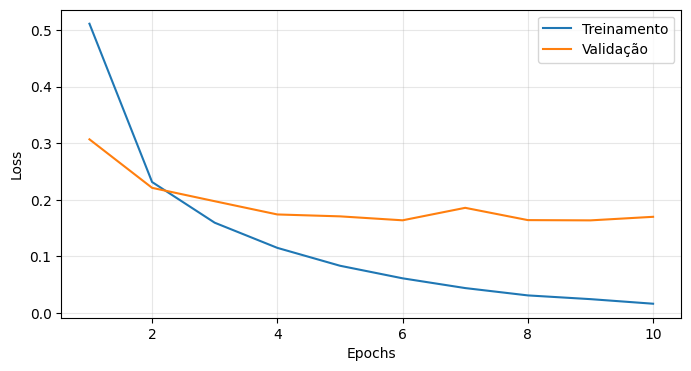

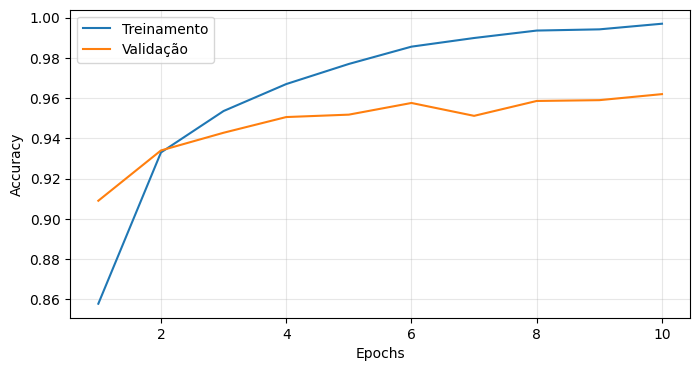

In [28]:
train_loss_values = history.history["loss"]
train_acc_values = history.history["accuracy"]
val_loss_values = history.history["val_loss"]
val_acc_values = history.history["val_accuracy"]

epochs = np.arange(1, len(train_loss_values) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_loss_values, label="Treinamento")
plt.plot(epochs, val_loss_values, label="Validação")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_acc_values, label="Treinamento")
plt.plot(epochs, val_acc_values, label="Validação")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [29]:
# Treinamento com 55000 amostras, mantendo os hiperparâmetros do modelo.
keras.utils.set_random_seed(42)

model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(150, activation="relu", name="layer1"),
    layers.Dense(150, activation="relu", name="layer2"),
    layers.Dense(10, activation="softmax", name="output")
])

model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

history = model.fit(
    x_train[:55000], y_train[:55000],
    epochs=20,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

train_loss, train_acc = model.evaluate(x_train[:55000], y_train[:55000], verbose=0)
val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)
print("Train accuracy: {:.2%}".format(train_acc))
print("Val accuracy:   {:.2%}".format(val_acc))


Epoch 1/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9248 - loss: 0.2575 - val_accuracy: 0.9644 - val_loss: 0.1171
Epoch 2/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9679 - loss: 0.1060 - val_accuracy: 0.9734 - val_loss: 0.0835
Epoch 3/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9786 - loss: 0.0713 - val_accuracy: 0.9768 - val_loss: 0.0744
Epoch 4/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9853 - loss: 0.0519 - val_accuracy: 0.9770 - val_loss: 0.0772
Epoch 5/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9887 - loss: 0.0390 - val_accuracy: 0.9776 - val_loss: 0.0847
Epoch 6/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9918 - loss: 0.0301 - val_accuracy: 0.9778 - val_loss: 0.0976
Epoch 7/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9931 - loss: 0.0239 - val_accuracy: 0.9782 - val_loss: 0.1037
Epoch 8/20
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9941 - loss: 0.0201 - val_accuracy: 0

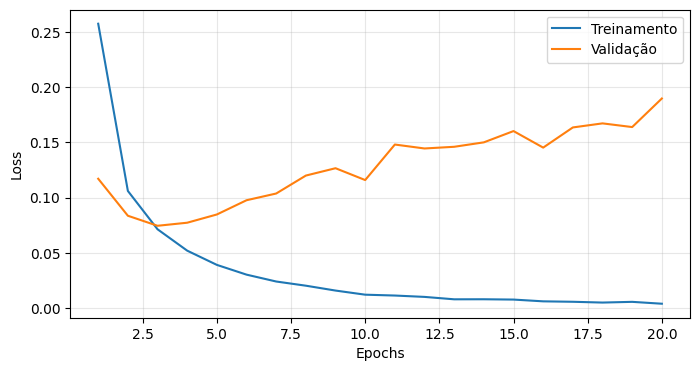

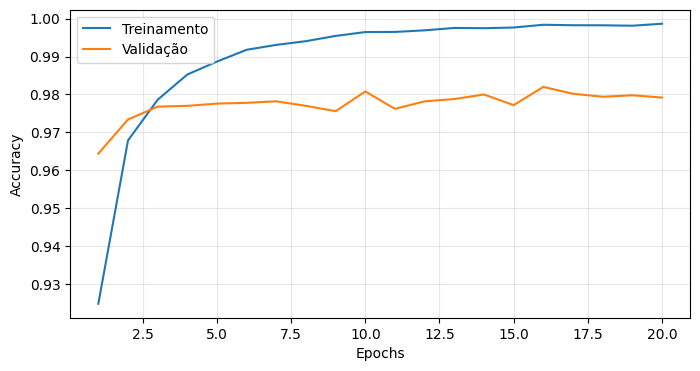

Best validation accuracy: 98.20%
Best epoch: 16


In [30]:
train_loss_values = history.history["loss"]
train_acc_values = history.history["accuracy"]
val_loss_values = history.history["val_loss"]
val_acc_values = history.history["val_accuracy"]

epochs = np.arange(1, len(train_loss_values) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_loss_values, label="Treinamento")
plt.plot(epochs, val_loss_values, label="Validação")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_acc_values, label="Treinamento")
plt.plot(epochs, val_acc_values, label="Validação")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_epoch = int(np.argmax(val_acc_values)) + 1
best_val_acc = float(np.max(val_acc_values))
print("Best validation accuracy: {:.2%}".format(best_val_acc))
print("Best epoch:", best_epoch)


In [31]:
'''
Learning curve: cada ponto usa um novo modelo, evitando continuar o
treinamento do modelo usado no ponto anterior.
'''
train_sizes = [5000, 15000, 25000, 35000, 45000, 55000]

learn_curve_acc_train = []
learn_curve_acc_val = []
learn_curve_best_epoch = []

for size in train_sizes:
    print("\nTrain set size:", size)
    keras.utils.set_random_seed(42)

    lc_model = keras.Sequential([
        keras.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(150, activation="relu", name="layer1"),
        layers.Dense(150, activation="relu", name="layer2"),
        layers.Dense(10, activation="softmax", name="output")
    ])

    lc_model.compile(
        optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    lc_history = lc_model.fit(
        x_train[:size], y_train[:size],
        epochs=20,
        batch_size=64,
        validation_data=(x_val, y_val),
        verbose=0
    )

    _, train_acc = lc_model.evaluate(x_train[:size], y_train[:size], verbose=0)
    val_acc_history = np.asarray(lc_history.history["val_accuracy"])
    best_val_acc = float(np.max(val_acc_history))
    best_epoch = int(np.argmax(val_acc_history)) + 1

    learn_curve_acc_train.append(float(train_acc))
    learn_curve_acc_val.append(best_val_acc)
    learn_curve_best_epoch.append(best_epoch)

    print("Train acc:", f"{train_acc:.2%}")
    print("Best val acc:", f"{best_val_acc:.2%}")
    print("Best epoch:", best_epoch)



Train set size: 5000
Train acc: 100.00%
Best val acc: 95.44%
Best epoch: 17

Train set size: 15000
Train acc: 99.93%
Best val acc: 97.30%
Best epoch: 17

Train set size: 25000
Train acc: 99.96%
Best val acc: 97.80%
Best epoch: 12

Train set size: 35000
Train acc: 99.95%
Best val acc: 98.04%
Best epoch: 17

Train set size: 45000
Train acc: 99.87%
Best val acc: 98.18%
Best epoch: 19

Train set size: 55000
Train acc: 99.60%
Best val acc: 98.20%
Best epoch: 16


Training accuracy: ['100.00%', '99.93%', '99.96%', '99.95%', '99.87%', '99.60%']
Best validation accuracy: ['95.44%', '97.30%', '97.80%', '98.04%', '98.18%', '98.20%']
Best epoch: [17, 17, 12, 17, 19, 16]


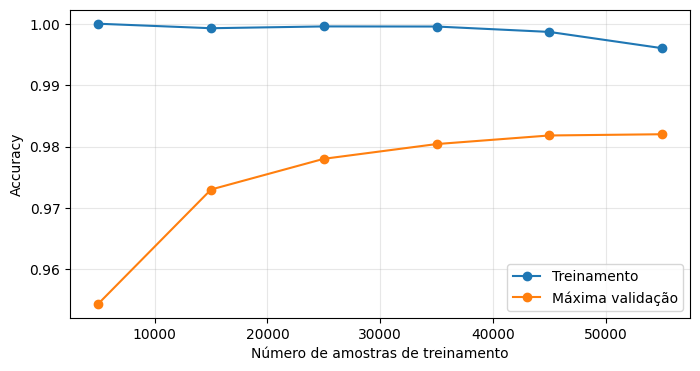

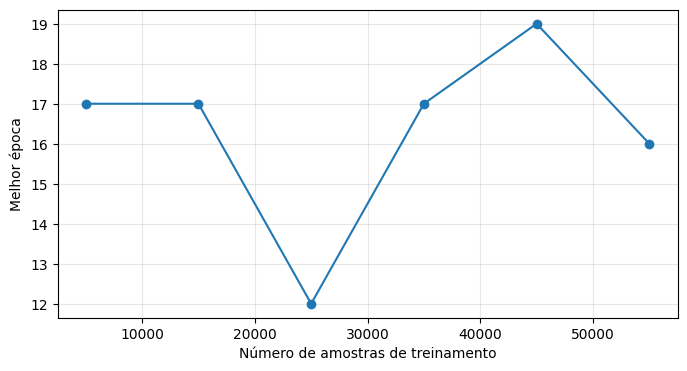

In [32]:
print("Training accuracy:", [f"{v:.2%}" for v in learn_curve_acc_train])
print("Best validation accuracy:", [f"{v:.2%}" for v in learn_curve_acc_val])
print("Best epoch:", learn_curve_best_epoch)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, learn_curve_acc_train, marker="o", label="Treinamento")
plt.plot(train_sizes, learn_curve_acc_val, marker="o", label="Máxima validação")
plt.xlabel("Número de amostras de treinamento")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, learn_curve_best_epoch, marker="o")
plt.xlabel("Número de amostras de treinamento")
plt.ylabel("Melhor época")
plt.grid(True, alpha=0.3)
plt.show()


#### Conclusões:

**R: a curva de aprendizado permite observar como o aumento do conjunto de treinamento afeta a capacidade de generalização. Em geral, conjuntos maiores reduzem a variabilidade do desempenho e tornam a acurácia de validação mais estável. A época de melhor validação também pode mudar com o tamanho do conjunto, pois conjuntos maiores podem exigir mais épocas para atingir o melhor desempenho. Como cada ponto foi obtido com um novo modelo, a comparação é metodologicamente consistente. A interpretação final deve ser feita a partir dos valores obtidos na execução do notebook.**

In [35]:
# Treinamento final com todas as 60000 amostras.
# O conjunto de teste permanece separado e só é utilizado para a avaliação final.
keras.utils.set_random_seed(42)

final_model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(150, activation="relu", name="layer1"),
    layers.Dense(150, activation="relu", name="layer2"),
    layers.Dense(10, activation="softmax", name="output")
])

final_model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

history_final = final_model.fit(
    x_train_full,
    y_train_full,
    epochs=20,
    batch_size=64,
    verbose=1
)

train_loss, train_acc = final_model.evaluate(x_train_full, y_train_full, verbose=0)
test_loss, test_acc = final_model.evaluate(x_test_full, y_test_full, verbose=0)

print("Train accuracy: {:.2%}".format(train_acc))
print("Test accuracy:  {:.2%}".format(test_acc))


Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9277 - loss: 0.2445
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9695 - loss: 0.1011
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9797 - loss: 0.0688
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9852 - loss: 0.0509
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9891 - loss: 0.0384
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9916 - loss: 0.0301
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9934 - loss: 0.0233
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9947 - loss: 0.0188
Epoch 9/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9953 - loss: 0.0160
Epoch 10/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9954 - loss: 0.0148
Epoch 11/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9963 - loss: 0.0117
Epoch 12/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

In [36]:
# Keras atual: predict() retorna as probabilidades
#              argmax() obtém a classe prevista.
y_prob = final_model.predict(x_test_full, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print("Number of predictions:", len(y_pred))
print("Number of test labels:", len(y_test_full))


Number of predictions: 10000
Number of test labels: 10000


Total incorrect predictions: 206
Number 2 predicted as 9


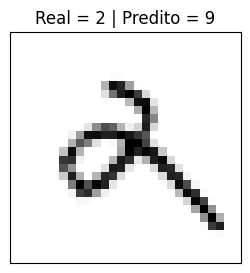

Number 9 predicted as 8


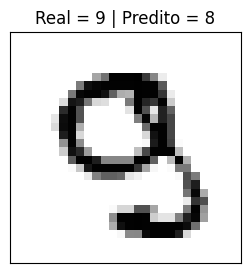

Number 4 predicted as 2


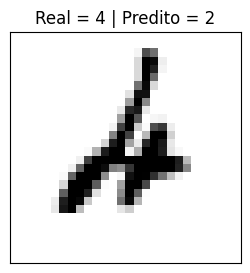

Number 2 predicted as 7


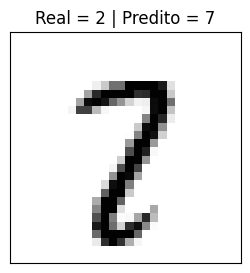

Number 5 predicted as 3


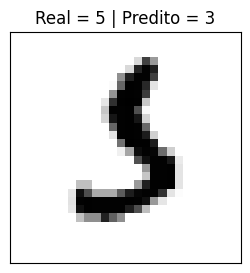

In [39]:
indices_errados = np.where(y_pred != y_test_full)[0]

print("Total incorrect predictions:", len(indices_errados))

for j in indices_errados[:5]:
    print("Number", y_test_full[j], "predicted as", y_pred[j])
    plt.figure(figsize=(3, 3))
    plt.imshow(x_test_full[j], cmap=plt.cm.gray_r)
    plt.title("Real = {} | Predito = {}".format(y_test_full[j], y_pred[j]))
    plt.xticks([])
    plt.yticks([])
    plt.show()


In [40]:
# Visualização dos pesos da primeira camada Dense.
W = final_model.get_layer("layer1").get_weights()[0]
vmax = np.abs(W).max()

@interact(i=(0, int(np.ceil(W.shape[1] / 10)) - 1))
def show_weights(i=0):
    plt.figure(figsize=(16, 2.4))
    start = 10 * i
    end = min(start + 10, W.shape[1])

    for j in range(start, end):
        plt.subplot(1, 10, j - start + 1)
        w = W[:, j].reshape(28, 28)
        plt.imshow(w, cmap=plt.cm.bwr, vmin=-vmax, vmax=vmax)
        plt.xticks([])
        plt.yticks([])

    plt.tight_layout()
    plt.show()


interactive(children=(IntSlider(value=0, description='i', max=14), Output()), _dom_classes=('widget-interact',…

In [41]:
W = model.weights[0].numpy()
vmax = np.abs(W).max()
@interact(i=(0,int(np.ceil(W.shape[1]/10))-1))
def _(i=0):
  plt.figure(figsize=(16,2.4));
  # para ver de 10 em 10
  for j in range(min(10, W.shape[1]-10*i)):
    plt.subplot(1,10,j+1)
    w = W[:,10*i+j].reshape(28,28)
    plt.imshow(w, cmap=plt.cm.bwr, vmin=-vmax, vmax=vmax); # (-,0,+) = (blue, white, red)
    plt.xticks([]);
    plt.yticks([]);

interactive(children=(IntSlider(value=0, description='i', max=14), Output()), _dom_classes=('widget-interact',…

11. Relate suas principais conclusões com este exercício.
1. (OPCIONAL) O que acontece se é aplicada uma permutação aleatória nos pixels de todas as imagens (a mesma permutação para todas as imagens)? O desempenho do modelo se altera? Você consegue identificar corretamente os dígitos? O que podemos concluir sobre o aprendizado do modelo?

#### Dicas
- Funções úteis: `plt.figure(figsize=(...))`, `plt.subplot()`, `plt.plot(..., label=...)`, `plt.xlabel()`, `plt.legend()`
- Quando usamos *early stopping*, perdemos parcialmente o controle sobre o número de épocas de treinamento como um hiperparâmetro. Nesse caso, após o desenvolvimento de um modelo, se desejarmos identificar seus hiperparâmetros, é conveniente registrar e fixar o número de épocas de treinamento efetivamente utilizadas e parar de utilizar *early stopping*.
- Se quiser salvar o melhor modelo encontrado, mas sem usar *early stopping*, você pode utilizar a *callback* `tf.keras.callbacks.ModelCheckpoint`. Alternativamente, você pode usar *early stopping* com uma paciência suficientemente grande (maior que o número de épocas).

#### Observações

**R11: Principais conclusões: o exercício mostra que a arquitetura e os hiperparâmetros influenciam diretamente a capacidade de aprendizado de uma rede neural. Para o MNIST, um modelo sem camadas ocultas funciona como baseline, mas camadas ocultas com ativação ReLU aumentam a capacidade de representar padrões não lineares e permitem obter desempenho significativamente melhor. A saída deve possuir 10 neurônios, correspondentes às dez classes do MNIST, com `softmax` na camada de saída. **

**A diferença entre as acurácias de treinamento, validação e teste deve ser analisada para avaliar a generalização. Uma acurácia de treinamento maior que a de validação/teste pode indicar algum grau de overfitting, mas não permite, isoladamente, concluir que existe ou não overfitting severo. As curvas de perda e acurácia ao longo das épocas fornecem evidências adicionais para essa análise.**

**A curva de aprendizado mostra como o desempenho varia com a quantidade de dados disponíveis. Ao aumentar o conjunto de treinamento, espera-se uma tendência de melhora ou estabilização da acurácia de validação. A análise da época de melhor validação também ajuda a verificar quanto treinamento é necessário para cada tamanho de conjunto. **

**Por fim, a inspeção das imagens classificadas incorretamente permite perceber que muitos erros correspondem a dígitos visualmente ambíguos. Isso evidencia que uma acurácia próxima de 100% não é necessária para que o modelo apresente boa capacidade de generalização.**


**Caso alguém tenha feito (acho difícil) Questão opcional: se a mesma permutação aleatória de pixels for aplicada a todas as imagens e o modelo for treinado novamente, uma rede totalmente conectada ainda pode aprender a classificação, pois ela não depende explicitamente da vizinhança espacial dos pixels. Assim, o desempenho pode permanecer relativamente próximo do obtido sem a permutação. Isso também evidencia uma limitação importante das redes densas para imagens: elas não exploram diretamente a estrutura espacial local, ao contrário das redes convolucionais. **